## Experimental Scenario 2: Heterogeneity Study ($\beta$)

The objective is to evaluate model robustness when faced with data fragmentation. We utilize three levels of concentration based on the Dirichlet distribution:

| Parameter | Difficulty Level | Statistical Description |
| :--- | :--- | :--- |
| **$\beta = 0.5$** | **High** | Strong heterogeneity: some clients become "experts" in a single class. |
| **$\beta = 5$** | **Medium** | Moderate heterogeneity: imbalance is present but manageable. |
| **$\beta = 100$** | **None** | Quasi-IID: uniform data distribution across the 10 clients. |



### Imports / Paths / Utils

In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

from fluke_package.fluke.data.datasets import Datasets
from fluke_package.fluke.nets import Diabetes_LR, Diabetes_SVM, Diabetes_MLP

# Configuration
BASE_PATH = Path('runs/NON-IID')
BETAS = ['0.5', '5', '100']
MODELS = ['LR', 'MLP', 'SVM']
COLORS = {'0.5': '#e74c3c', '5': '#f1c40f', '100': '#2ecc71'} # Couleurs par Beta
STYLES = {'LR': '-', 'MLP': '--', 'SVM': ':'}

data_container = Datasets.DIABETES()


def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')


def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None


def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


cwd = Path.cwd()
print(f"Current working directory: {cwd}")
base = cwd / 'runs'
print(f"Looking for runs in: {base}")

[TqdmWarning] c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation\fluke310\Lib\site-packages\tqdm\auto.py:21
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



Distribution of target (Diabetes_binary) :
   - No Diabetes ((0,)): 218334 persons (86.07%)
   - No Diabetes ((1,)): 35346 persons (13.93%)
--------------------------------------------------
Sensible variable 'Sex' detected at index : 17

Size of the dataset :
   - Train set : 202944 samples, 21 features
   - Test set  : 50736 samples
--------------------------------------------------
Current working directory: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation
Looking for runs in: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation\runs


### Utility metrics

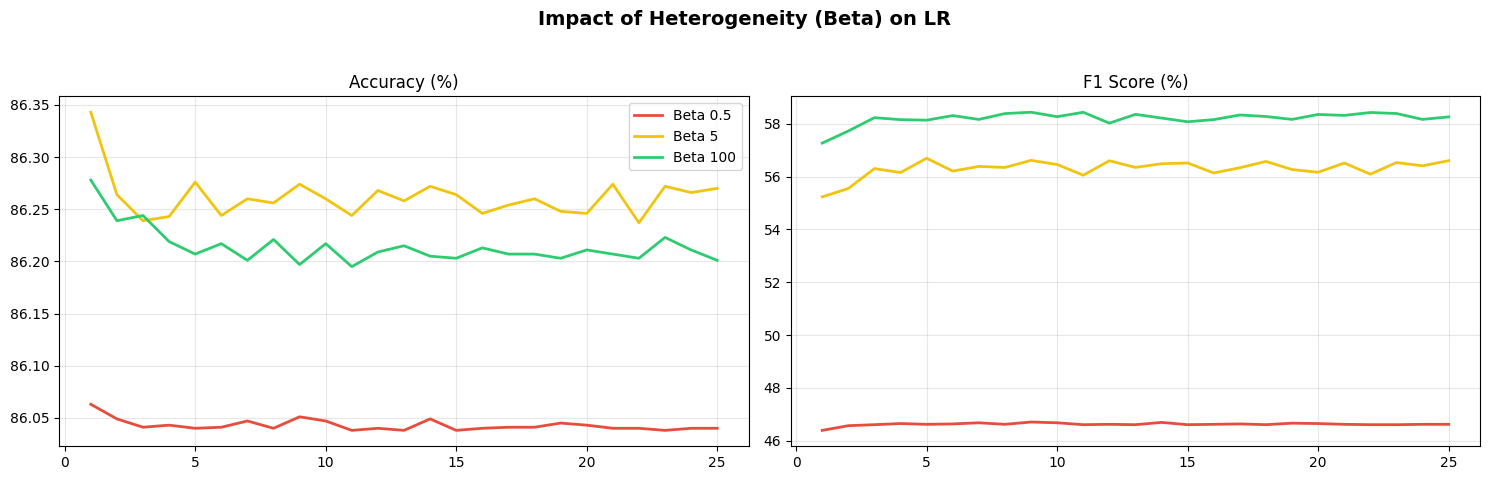

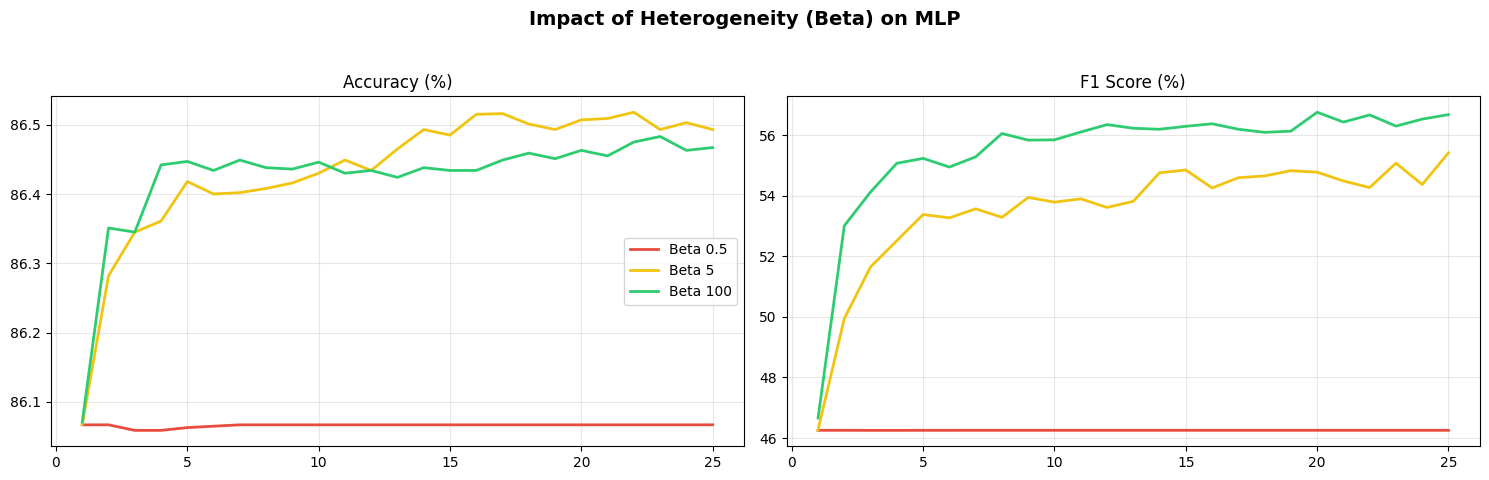

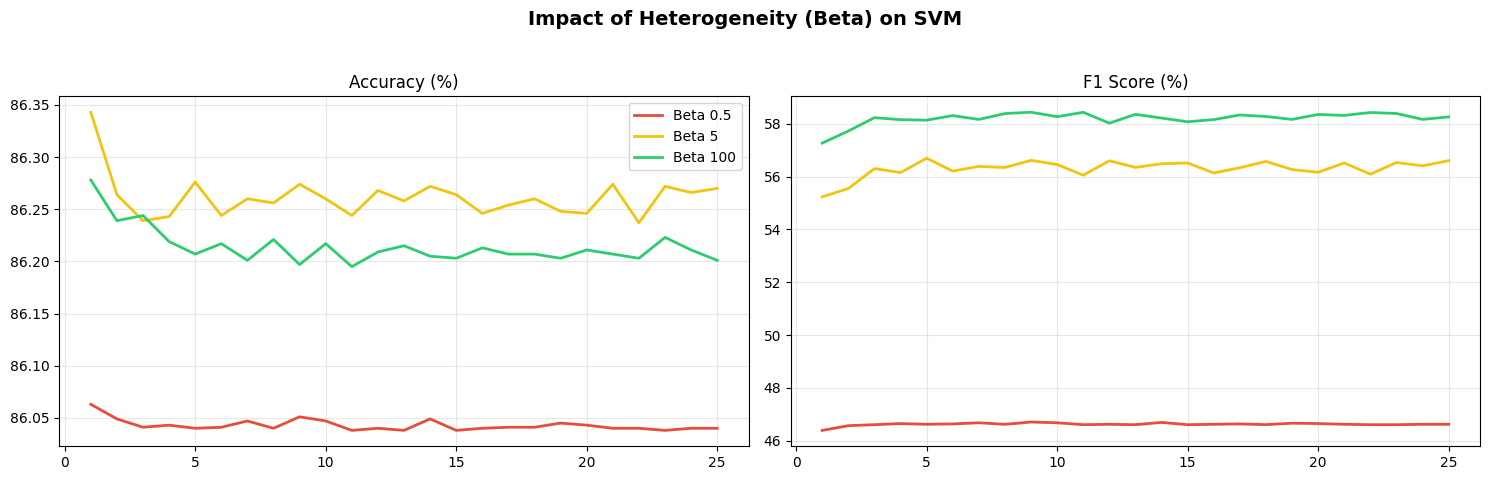

In [4]:
def plot_utility_non_iid(base_path, betas, models):
    plots = [('accuracy', 'Accuracy (%)'), ('macro_f1', 'F1 Score (%)')]

    for m_name in models:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        fig.suptitle(f'Impact of Heterogeneity (Beta) on {m_name}', fontsize=14, fontweight='bold')
        
        for beta in betas:
            # On pointe vers le dossier du modèle (load_global_metrics cherchera le CSV dedans)
            model_run_path = base_path / str(beta) / m_name
            try:
                # Utilisation de ta fonction load_global_metrics
                df = load_global_metrics(model_run_path)
                
                for i, (col, title) in enumerate(plots):
                    actual_col = col if col in df.columns else f'test_{col}'
                    if actual_col in df.columns:
                        axes[i].plot(df['round'], df[actual_col] * 100, 
                                     label=f'Beta {beta}', color=COLORS[str(beta)], lw=2)
                        axes[i].set_title(title)
                        axes[i].grid(True, alpha=0.3)
            except Exception as e:
                print(f"⚠️ Erreur pour {m_name} Beta {beta}: {e}")
        
        axes[0].legend()
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

plot_utility_non_iid(BASE_PATH, BETAS, MODELS)

### Confusion matrix

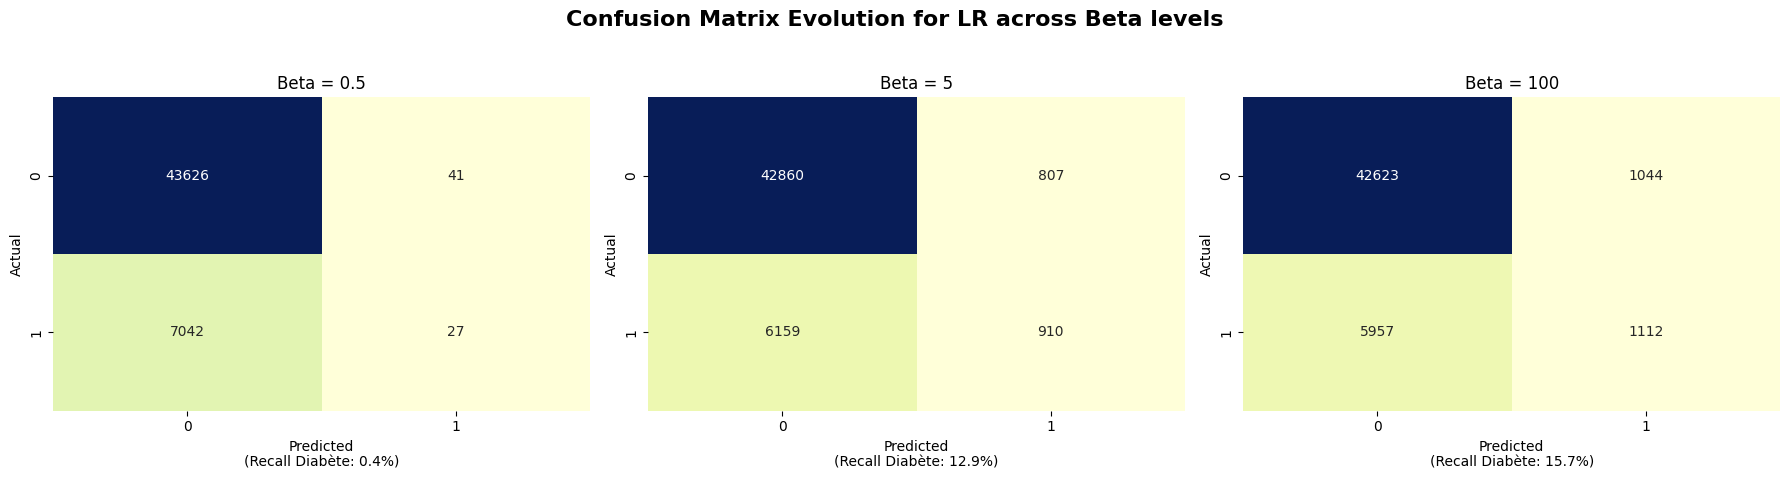

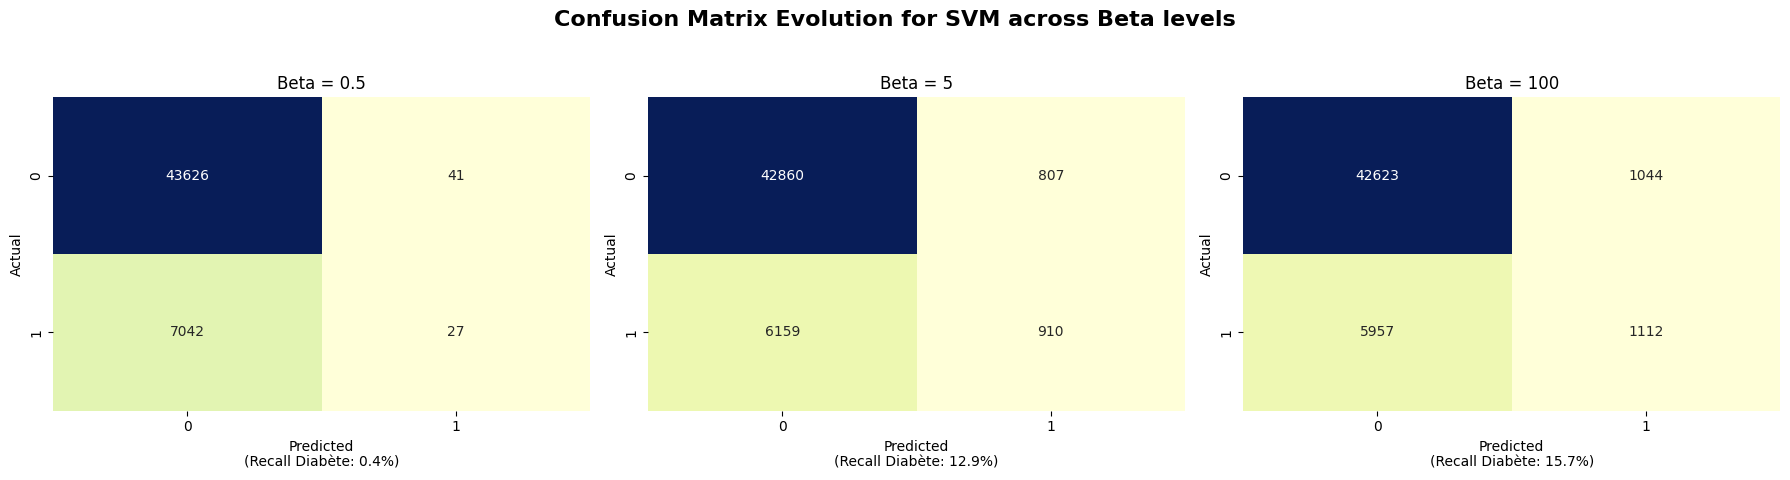

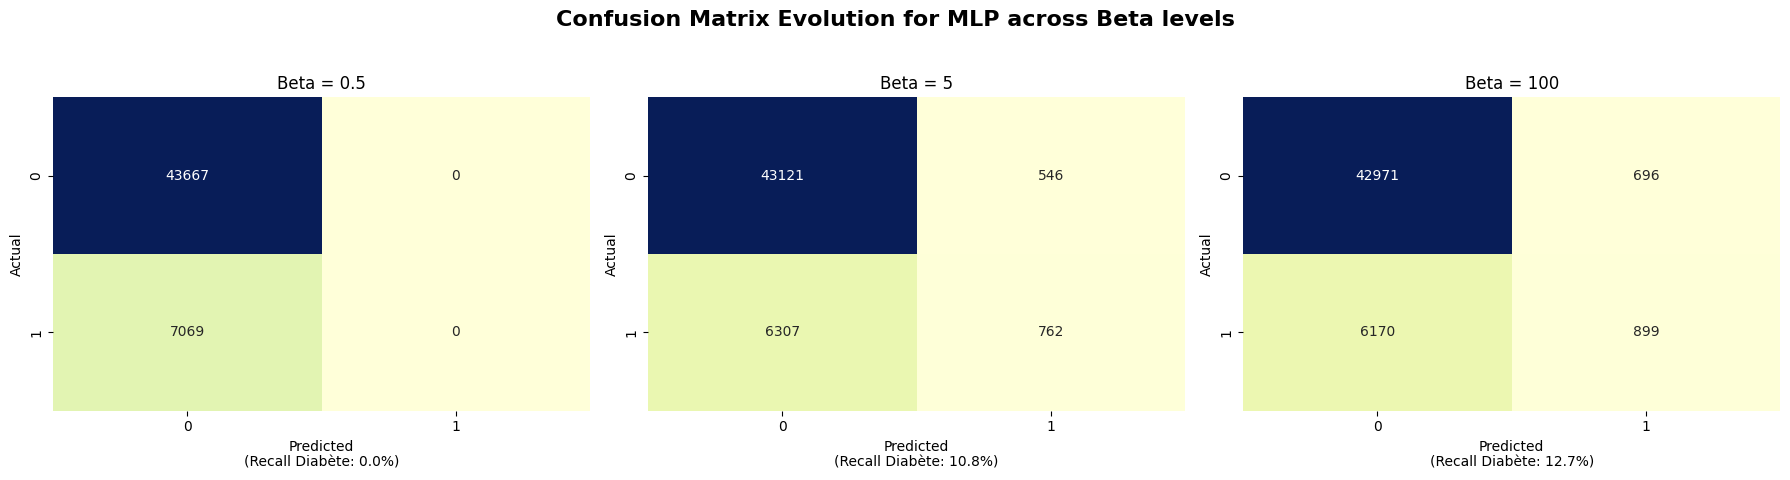

In [12]:
def plot_confusion_beta_comparison(base_path, model_name, data):
    X_test, y_test = data.test
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrix Evolution for {model_name} across Beta levels', fontsize=16, fontweight='bold')
    
    model_classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}

    for i, beta in enumerate(BETAS):
        model_folder = base_path / str(beta) / model_name
        # On utilise rglob pour trouver le fichier pth dans le sous-dossier hashé
        pth_file = next(model_folder.rglob("final_model.pth"), None)
        
        if pth_file:
            # Reconstruction du modèle et chargement des poids
            model = model_classes[model_name](input_dim=21)
            model.load_state_dict(torch.load(pth_file, map_location='cpu'))
            model.eval()
            
            with torch.no_grad():
                preds = torch.argmax(model(X_test), dim=1)
            
            cm = confusion_matrix(y_test, preds)
            
            # Affichage de la heatmap
            sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i], cbar=False)
            axes[i].set_title(f'Beta = {beta}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('Actual')
            
            # Optionnel : Calcul du Recall de la classe Diabète (classe 1) pour l'affichage
            recall_1 = cm[1,1] / (cm[1,0] + cm[1,1]) * 100 if (cm[1,0] + cm[1,1]) > 0 else 0
            axes[i].set_xlabel(f'Predicted\n(Recall Diabète: {recall_1:.1f}%)')
        else:
            axes[i].text(0.5, 0.5, f'Model not found\n(Beta {beta})', 
                         ha='center', va='center')
            axes[i].set_title(f'Beta = {beta}')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Exemple : Comparer l'évolution pour le MLP
plot_confusion_beta_comparison(BASE_PATH, 'LR', data_container)
plot_confusion_beta_comparison(BASE_PATH, 'SVM', data_container)
plot_confusion_beta_comparison(BASE_PATH, 'MLP', data_container)

### Cost metrics

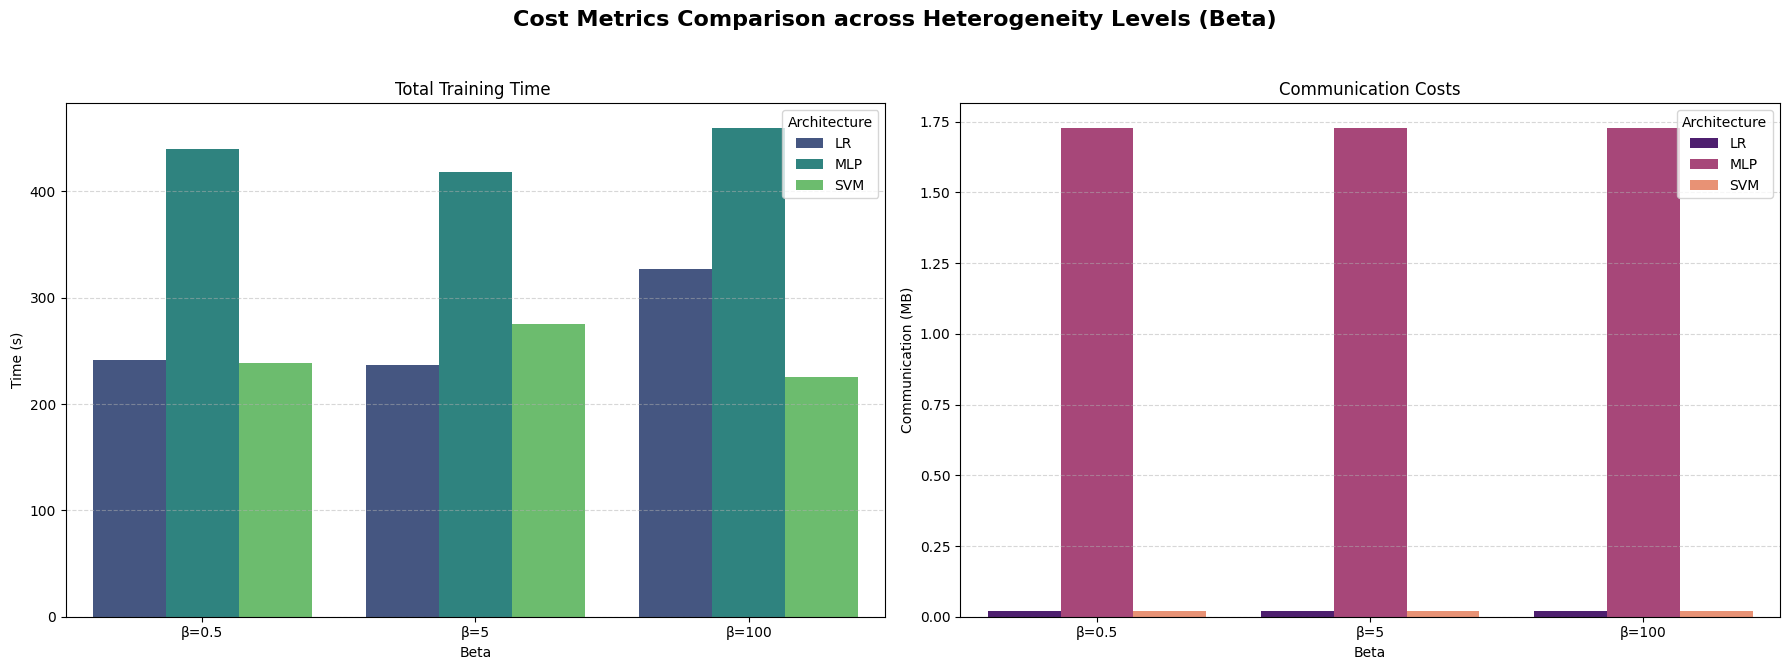

In [8]:
def plot_costs_beta_comparison(base_path, betas, models):
    cost_data = []

    for beta in betas:
        for m in models:
            run_path = base_path / str(beta) / m
            
            # Temps via ta fonction
            t = load_run_time(run_path)
            
            # Comms via ta fonction (somme totale des coûts)
            df_c = load_comm_costs(run_path)
            c = df_c['comm_costs'].sum() / (1024**2) if df_c is not None else 0
            
            if t is not None:
                cost_data.append({
                    'Beta': f'β={beta}',
                    'Model': m,
                    'Time (s)': t,
                    'Communication (MB)': c
                })

    df_cost = pd.DataFrame(cost_data)

    # Création des graphiques
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('Cost Metrics Comparison across Heterogeneity Levels (Beta)', fontsize=16, fontweight='bold')

    # Graphique 1 : Temps d'entraînement (Groupé par Beta)
    sns.barplot(data=df_cost, x='Beta', y='Time (s)', hue='Model', ax=ax1, palette='viridis')
    ax1.set_title('Total Training Time ')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Graphique 2 : Communication (Groupé par Beta)
    sns.barplot(data=df_cost, x='Beta', y='Communication (MB)', hue='Model', ax=ax2, palette='magma')
    ax2.set_title('Communication Costs')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Amélioration des légendes
    ax1.legend(title='Architecture')
    ax2.legend(title='Architecture')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Exécution
plot_costs_beta_comparison(BASE_PATH, BETAS, MODELS)

### Fairness metrics

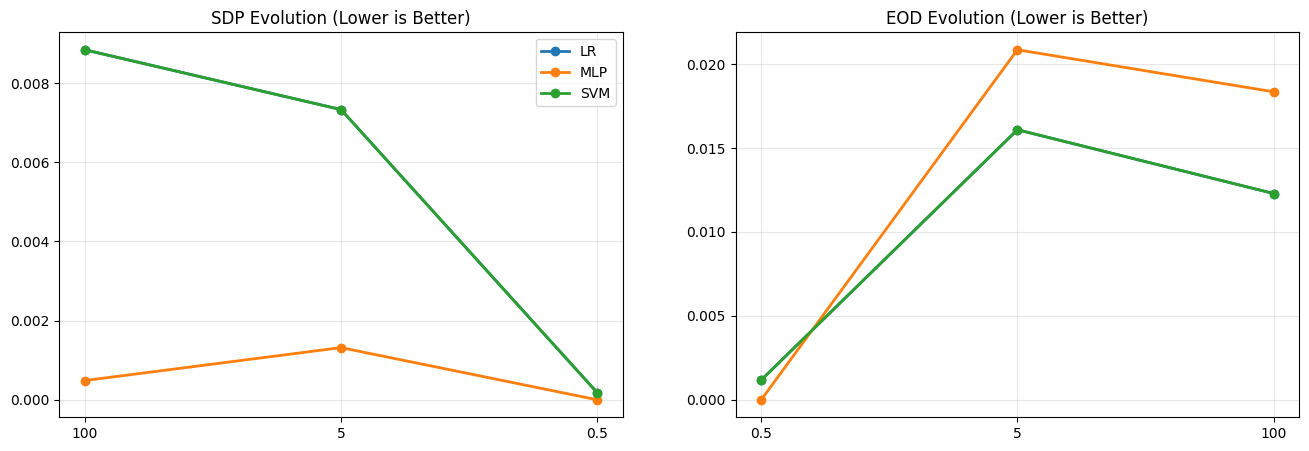

In [5]:
def compute_fairness_for_all(paths, data_container, sex_index=17):
    X_test, y_test = data_container.test
    results = {}
    
    model_classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}
    
    # Masques de groupes (Sex: 1 vs 0)
    g1_mask = (X_test[:, sex_index] > 0)
    g0_mask = (X_test[:, sex_index] <= 0)
    mask_y1 = (y_test == 1)

    def get_rate(predictions, mask):
        return predictions[mask].float().mean().item() if mask.any() else 0.0

    for name, path in paths.items():
        model_file = path / 'final_model.pth'
        if not model_file.exists() or name not in model_classes:
            continue

        # Chargement du modèle
        model = model_classes[name](input_dim=21)
        model.load_state_dict(torch.load(model_file, map_location='cpu'))
        model.eval()

        with torch.no_grad():
            preds = torch.argmax(model(X_test), dim=1)

        # Calcul SDP : |P(pred=1|G=1) - P(pred=1|G=0)|
        sdp = abs(get_rate(preds, g1_mask) - get_rate(preds, g0_mask))

        # Calcul EOD : |P(pred=1|G=1, y=1) - P(pred=1|G=0, y=1)|
        eod = abs(get_rate(preds, g1_mask & mask_y1) - get_rate(preds, g0_mask & mask_y1))

        results[name] = {'SDP': sdp, 'EOD': eod}
    
    return results

def plot_fairness_evolution(base_path, betas, models, data):
    fairness_stats = []
    
    for beta in betas:
        # Construction d'un dictionnaire de chemins pour compute_fairness_for_all
        paths_beta = {}
        for m in models:
            # rglob pour trouver le dossier hashé qui contient le modèle
            model_file = next((base_path / str(beta) / m).rglob("final_model.pth"), None)
            if model_file:
                paths_beta[m] = model_file.parent
            
        res = compute_fairness_for_all(paths_beta, data)
        for m_name, metrics in res.items():
            fairness_stats.append({'Beta': beta, 'Model': m_name, **metrics})

    df_fair = pd.DataFrame(fairness_stats)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    for m in models:
        subset = df_fair[df_fair['Model'] == m]
        ax1.plot(subset['Beta'], subset['SDP'], marker='o', label=m, lw=2)
        ax2.plot(subset['Beta'], subset['EOD'], marker='o', label=m, lw=2)
    
    ax1.set_title('SDP Evolution (Lower is Better)')
    ax2.set_title('EOD Evolution (Lower is Better)')
    ax1.invert_xaxis() # De IID vers Non-IID
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3)
    plt.show()

plot_fairness_evolution(BASE_PATH, BETAS, MODELS, data_container)